# Config

Max Fan Load Power: 33.60W


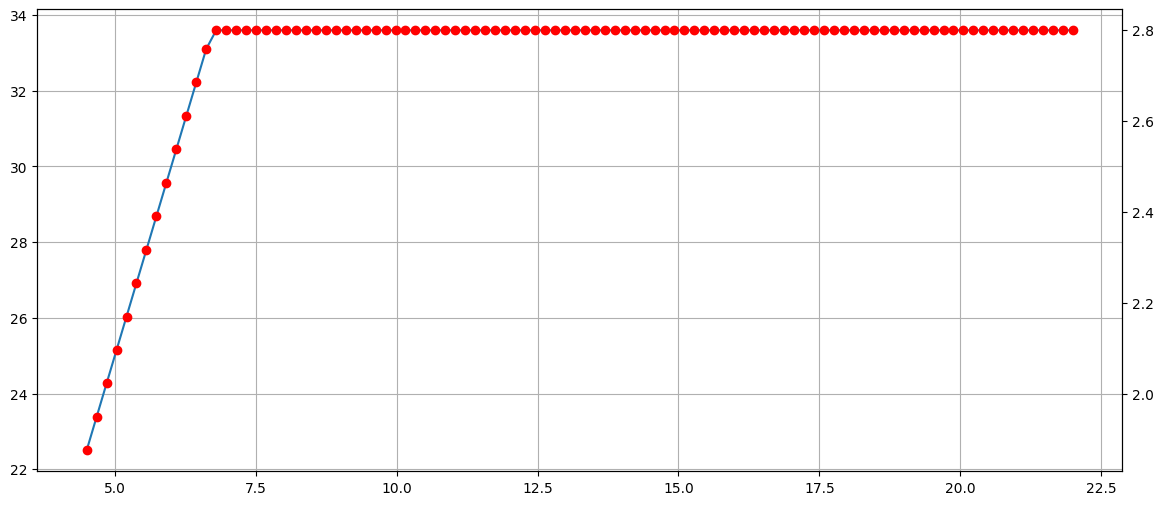

c_out r_esr: 18.34 mOhm


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#USB-C power sources, 5V to 20V, 5A
v_in_min_nominal = 5
v_in_max_nominal = 20
usb_c_v_tolerance = 0.1 # 10% tolerance
v_in = np.linspace(v_in_min_nominal*(1-usb_c_v_tolerance), v_in_max_nominal*(1+usb_c_v_tolerance), 100)
i_in_max = 5 # USB-C PD max current
i_in_nom_max = 3 # common USB-C maximum current
v_out = 12
fan_p14_pro_max_current = 0.35
fan_p14_pwm_max_current = 0.12
max_number_p14_pro = 8
max_load_watts = v_out * fan_p14_pro_max_current * max_number_p14_pro
print(f"Max Fan Load Power: {max_load_watts:.2f}W")

input_voltage_operating_points = v_in
input_current_operating_points_max = np.full_like(input_voltage_operating_points,i_in_nom_max)
f_sw = 100e3 # Assume we use minimum frequency. Helps lower switching mosfet losses. Though increases inductor core/ac losses.

# Calculate max power at each point: min(Available Input Power, Load Limit)
p_out_operating_points = np.minimum(max_load_watts, v_in * i_in_max)
i_out_operating_points = p_out_operating_points / v_out


fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
ax1.plot(v_in, p_out_operating_points, label='Output Power [W]')
ax2.plot(v_in, i_out_operating_points, 'o', color = "red", label='Output Current [A]')
ax1.grid()
plt.show()

L1 = 47e-6 # from 1_.pynb
c_out_chosen_nominal = 4.7e-3 * 4
c_out_chosen_derated = 4.7e-3 * 4 * 0.7 # 4 4700 uF with 70% dc bias derating
c_out_dissipation_factor = 0.16 + 0.02 * 5
f_df = 120
r_esr = c_out_dissipation_factor / (2 * np.pi * f_df * c_out_chosen_nominal)
print(f"c_out r_esr: {r_esr*1000:.2f} mOhm")

In [ ]:
# Power Budget

In [ ]:
# minimum max power sourve
power_source = 45
load = 42
inductor = 0.3
mosfet = 0.3
esp32 = 3.3 * 0.4
buck_5v_loss = 3.3*0.4 / 0.9 - 3.3 * 0.4
cs_shunt = 0.01 * 8 * np.sqrt(2) #asume 8 amp inductor current and 50% duty cycle
in_shunt
remaining = power_source - load - inductor - mosfet - esp32 - buck_5v_loss - cs_shunt


print(remaining)

0.8201962483434859
